# 线性代数

## 1、标量

**简单操作**

1. c = a + b
2. c = a * b
3. c = sin a

**长度**

1. |a| = { a , a>=0
         { -a , a<0
2. |a+b| <= |a| + |b|
3. |a·b| = |a| * |b|

## 2、向量

**简单操作**

1. c = a + b where ci = ai + bi
2. c = α·b where ci = α bi
3. c = sin a where ci = sin ai

对于向量 a b c 而言，其运算就是对其每个对应位置 i 做对应运算

**长度**

1. 向量的长度就是对其每个部分的元素的平方求和后再开根号
2. 向量的长度恒大于等于0 （绝对值的性质）
3. ||a+b|| <= ||a||+||b||
4. ||a·b|| = |a|·||b||

点乘： a·b=Σai*bi

正交： 点乘 a·b=0

## 3、矩阵

**简单操作**

1. C=A+B  where Cij=Aij+Bij
2. C=α·B  where Cij=α * Bij
3. C=sin A  where Cij=sin Aij

**乘法**（矩阵乘以向量）

c = Ab where ci = Σj Aij * bj   矩阵乘以一个列向量，将矩阵的每一行对应位置与该列向量相乘得到

（或者直接视为矩阵乘以矩阵——行×列）设矩阵A的形状为(m x n)，矩阵B的形状为(n x p)，则它们的乘积C=AB的形状为(m x p)

矩阵乘以向量直观上来说是将空间进行了扭曲，从一个向量变成了另一种向量

**乘法**（矩阵乘以矩阵）

C = AB where Cik = Σj Aij * Bjk

设矩阵A的形状为(m x n)，矩阵B的形状为(n x p)，则它们的乘积C=AB的形状为(m x p)

**范数**

c = A · b   --->   ||c|| <= ||A|| · ||b|| 
取决于如何衡量b和c的长度

**常见范数**

1. 矩阵范数：最小的满足的上面公式的值
2. Frobenius范数：把矩阵的每个元素平方后相加再开根号

**特殊矩阵**

1. 对称和反对称： Aij = Aji and Aij = -Aji
2. 正定：一个矩阵乘以任意一个列向量或一个横向量他都大于等于0
   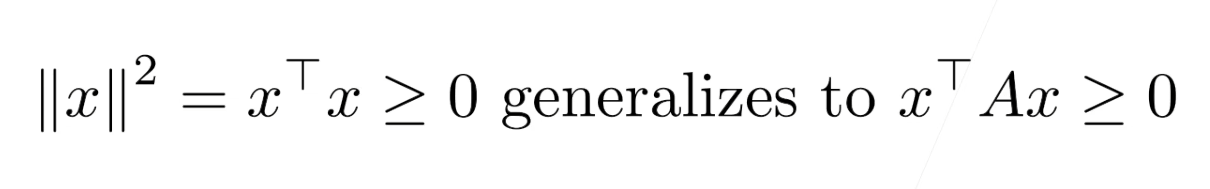
3. 正交矩阵：所有行都相许正交 ；
    所有行都有单位长度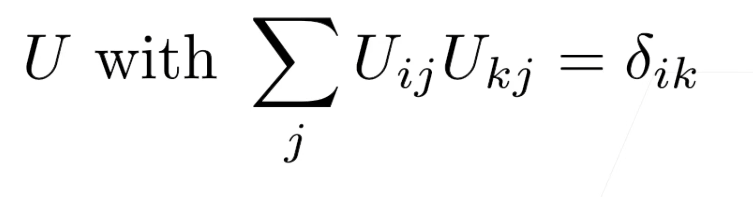 即U和U的转置相乘等于一个对角线全为1的单位矩阵，
    可以写成如下形式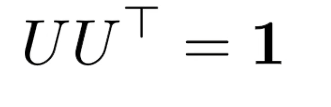
4. 置换矩阵：置换矩阵是正交矩阵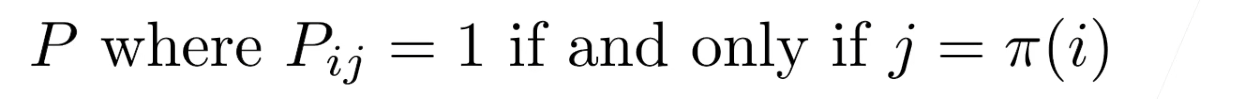矩阵P的构造规则：第 i行中，只有第j=π(i)列为 1，其余为 0【其中π 是一个置换，即对集合{1,2,…,n} 的一个双射】

**特征向量和特征值**

1. 不被矩阵改变方向的向量，即 Ax=λx 中的x就是特征向量
2. 对称矩阵总是可以找到特征向量

# 线性代数实现

## 1、标量

标量由只有一个元素的张量表示

In [3]:
import torch

x = torch.tensor([3.0])
y = torch.tensor([2.0])

x+y,x*y,x/y,x**y

(tensor([5.]), tensor([6.]), tensor([1.5000]), tensor([9.]))

## 2、向量

可以将向量视为标量值组成的列表

In [4]:
x = torch.arange(4)
x

tensor([0, 1, 2, 3])

通过张量的索引来访问任一元素

In [5]:
x[3]

tensor(3)

访问张量的长度

In [6]:
len(x)

4

只有一个轴的张量，形状shape只有一个元素

In [7]:
x.shape

torch.Size([4])

## 3、矩阵

通过指定两个分量m和n来创建一个形状shape为 m×n 的矩阵

In [8]:
A = torch.arange(20).reshape(5,4)
A

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15],
        [16, 17, 18, 19]])

矩阵的转置——将矩阵做了一个轴对称的翻转

In [9]:
A.T

tensor([[ 0,  4,  8, 12, 16],
        [ 1,  5,  9, 13, 17],
        [ 2,  6, 10, 14, 18],
        [ 3,  7, 11, 15, 19]])

对称矩阵A与其转置相等：A=AT

In [10]:
B = torch.tensor([[1,2,3],[2,0,4],[3,4,5]])
B

tensor([[1, 2, 3],
        [2, 0, 4],
        [3, 4, 5]])

In [11]:
B == B.T
#由输出可以看出来B是一个转置矩阵

tensor([[True, True, True],
        [True, True, True],
        [True, True, True]])

## 4、张量

就像向量是标量的推广，矩阵是向量的推广，我们也可以构建具有更多轴的数据结构（张量）

In [12]:
x = torch.arange(24).reshape(2,3,4) #（第一维）块-2是最外的维度，（最后一维）列-4是最内的维度
x

tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

给定具有相同形状的任何两个张量，任何按元素二元u那算的结果都将是相同形状的张量

In [13]:
A = torch.arange(20,dtype=torch.float32).reshape(5,4)
B = A.clone() #通过分配新内存，将A的一个副本分配给B,torch的clone是深拷贝
A,A+B

(tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.],
         [12., 13., 14., 15.],
         [16., 17., 18., 19.]]),
 tensor([[ 0.,  2.,  4.,  6.],
         [ 8., 10., 12., 14.],
         [16., 18., 20., 22.],
         [24., 26., 28., 30.],
         [32., 34., 36., 38.]]))

## 5、运算

两个矩阵的按元素乘法称为 哈达玛积 （数学符号表示为⊙）

In [15]:
A * B

tensor([[  0.,   1.,   4.,   9.],
        [ 16.,  25.,  36.,  49.],
        [ 64.,  81., 100., 121.],
        [144., 169., 196., 225.],
        [256., 289., 324., 361.]])

In [19]:
a = 2
X = torch.arange(24).reshape(2,3,4)
a+X,(a*X).shape
# 其实就是广播机制

(tensor([[[ 2,  3,  4,  5],
          [ 6,  7,  8,  9],
          [10, 11, 12, 13]],
 
         [[14, 15, 16, 17],
          [18, 19, 20, 21],
          [22, 23, 24, 25]]]),
 torch.Size([2, 3, 4]))

我们可以通过sum函数来计算其元素的和，得到的结果一定是一个标量

In [21]:
x = torch.arange(4,dtype=torch.float32)
x , x.sum()

(tensor([0., 1., 2., 3.]), tensor(6.))

表示任意形状张量的元素和

In [63]:
A = torch.arange(20).reshape(5,4)
A.shape,A.sum()

(torch.Size([5, 4]), tensor(190))

指定求和 汇总张量的轴

In [64]:
A_sum_axis0 = A.sum(axis=0)
A_sum_axis0 , A_sum_axis0.shape
# 对第0轴求和

(tensor([40, 45, 50, 55]), torch.Size([4]))

In [65]:
A_sum_axis1 = A.sum(axis=1)
A_sum_axis1 , A_sum_axis1.shape
# 对第1轴求和

(tensor([ 6, 22, 38, 54, 70]), torch.Size([5]))

In [68]:
A.sum(axis=[0,1])
# 对两个轴求和 此时等同于直接 sum

tensor(190)

一个与求和相关的量：平均值

In [69]:
A.float().mean() , A.sum()/A.numel()
# 注：这里直接用A.mean()会报错 pytorch的.mean()方法只接收float类型或者复数类型的计算

(tensor(9.5000), tensor(9.5000))

In [70]:
A.float().mean(axis=0) , A.sum(axis=0)/A.shape[0]
# 对某一维度求平均值

(tensor([ 8.,  9., 10., 11.]), tensor([ 8.,  9., 10., 11.]))

在调用函数计算总和或均值时可以保持轴数不变，有时候会很方便

In [71]:
sum_A = A.sum(axis=1,keepdims=True) #keepdims=true表示让维度固定不变
sum_A
# 保持第1轴不变

tensor([[ 6],
        [22],
        [38],
        [54],
        [70]])

通过广播机制用 `A` 除以 `sum_A` 

In [72]:
A / sum_A

tensor([[0.0000, 0.1667, 0.3333, 0.5000],
        [0.1818, 0.2273, 0.2727, 0.3182],
        [0.2105, 0.2368, 0.2632, 0.2895],
        [0.2222, 0.2407, 0.2593, 0.2778],
        [0.2286, 0.2429, 0.2571, 0.2714]])

某个轴计算 `A` 元素的累加求和

In [73]:
A.cumsum(axis=0)

tensor([[ 0,  1,  2,  3],
        [ 4,  6,  8, 10],
        [12, 15, 18, 21],
        [24, 28, 32, 36],
        [40, 45, 50, 55]])

点积 是相同位置的按元素乘积的和

In [74]:
y = torch.ones(4,dtype=torch.float32)
x, y, torch.dot(x,y) #dot表示点积运算

(tensor([0., 1., 2., 3.]), tensor([1., 1., 1., 1.]), tensor(6.))

我们可以通过执行按元素乘法，然后进行求和来表示两个向量的点积

In [75]:
torch.sum(x*y)

tensor(6.)

矩阵向量积 Ax 是一个长度为m 的列向量，其i^th^元素是点积a~i~^T^x（a的第i行与x做点积）

In [83]:
A.shape, x.shape, torch.mv(A.float(), x)  #pytorch中用 .mv() 计算 and 这里原来的A是int型的 需要转换类型后才能用
# 注意遵循矩阵乘法的原则 

(torch.Size([5, 4]), torch.Size([4]), tensor([ 14.,  38.,  62.,  86., 110.]))

两个矩阵做乘法`AB`：我们可以将其看作是简单地执行m次矩阵向量积，并将结果拼接到一起，形成一个n×m矩阵

In [87]:
B = torch.ones(4,3)
torch.mm(A.float(),B)
# mm 表示两个矩阵做乘法 注意也要复合矩阵乘法的规则

tensor([[ 6.,  6.,  6.],
        [22., 22., 22.],
        [38., 38., 38.],
        [54., 54., 54.],
        [70., 70., 70.]])

L2范数（表示长度）是向量所有元素平方和的平方根：

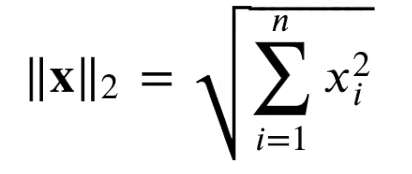

In [88]:
u = torch.tensor([3.0,-4.0])
torch.norm(u)
# .norm() 方法用来计算范数

tensor(5.)

L1范数：表示为向量元素的绝对值之和：

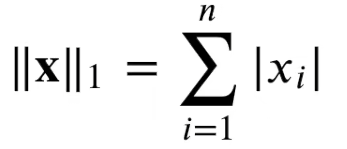

In [89]:
torch.abs(u).sum()

tensor(7.)

矩阵的 费罗贝尼乌斯范数：是矩阵元素的平方和的平方根

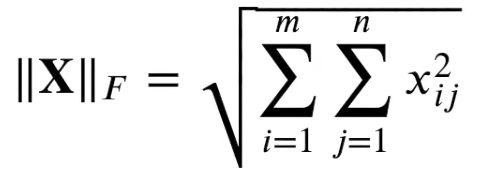

In [91]:
torch.norm(torch.ones((4,9)))

tensor(6.)

# 按特定轴求和

**——主要是对于上一部分中这个内容的补充理解**

比如说 一个矩阵 shape为[5,4] 对axis=0求和

这里是axis=0，相当于把[5,4]中的“5”消去，只保留下来“4”

按行求和，一行一行相加，最后就只剩一行；按列求和，一列一列相加，最后只剩一列

**keepdims=true** 是让其形状不变，只将对应的轴变为1

比如说shape[2,5,4] 的矩阵，对axis=1求和得到的shape为[2,1,4]，对axis=[1,2]求和得到的shape为[2,1,1]

**示例**

In [94]:
import torch

a = torch.ones((2,5,4))
a,a.shape

(tensor([[[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]],
 
         [[1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.],
          [1., 1., 1., 1.]]]),
 torch.Size([2, 5, 4]))

In [95]:
a.sum().shape

torch.Size([])

In [97]:
a.sum(axis=1),a.sum(axis=1).shape

(tensor([[5., 5., 5., 5.],
         [5., 5., 5., 5.]]),
 torch.Size([2, 4]))

In [98]:
a.sum(axis=0),a.sum(axis=0).shape

(tensor([[2., 2., 2., 2.],
         [2., 2., 2., 2.],
         [2., 2., 2., 2.],
         [2., 2., 2., 2.],
         [2., 2., 2., 2.]]),
 torch.Size([5, 4]))

In [99]:
a.sum(axis=[0,2]),a.sum(axis=[0,2]).shape

(tensor([8., 8., 8., 8., 8.]), torch.Size([5]))

In [101]:
a.sum(axis=1,keepdims=True),a.sum(axis=1,keepdims=True).shape

(tensor([[[5., 5., 5., 5.]],
 
         [[5., 5., 5., 5.]]]),
 torch.Size([2, 1, 4]))

In [102]:
a.sum(axis=[0,2],keepdims=True),a.sum(axis=[0,2],keepdims=True).shape

(tensor([[[8.],
          [8.],
          [8.],
          [8.],
          [8.]]]),
 torch.Size([1, 5, 1]))